# EDA structuré - AI4BMI (Maintenance prédictive)

Ce notebook réalise une analyse exploratoire complète du dataset `AI4BMI_predictive_maintenance_dataset.csv` pour préparer l'entraînement d'un modèle de prédiction de panne à 24h (`failure_next_24h`).

## Plan du notebook
1. Chargement et typage explicite
2. Audit du schéma réel vs documentation
3. Qualité et cohérence des données
4. Analyse descriptive (distribution, outliers, corrélations)
5. Analyse de la cible et signaux prédictifs
6. Analyse temporelle
7. Préparation à l'entraînement
8. Conclusions et recommandations modèle

In [13]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

In [14]:
# Chargement des données + typage explicite
CSV_PATH = 'AI4BMI_predictive_maintenance_dataset.csv'
df = pd.read_csv(CSV_PATH)

# Schéma attendu (adapté au CSV réel)
id_cols = ['machine_id', 'machine_type']
time_cols = ['timestamp']
numeric_cols_expected = [
    'maintenance_age_days',
    'vib_mean', 'vib_std', 'vib_rms',
    'temp_mean', 'temp_max',
    'current_mean', 'current_peak',
    'acoustic_energy',
    'rpm_mean',
    'oil_particle_count'
]
target_col = 'failure_next_24h'

# Cast types
for col in id_cols:
    if col in df.columns:
        df[col] = df[col].astype('string')

if 'machine_type' in df.columns:
    df['machine_type'] = df['machine_type'].astype('category')

if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

for col in numeric_cols_expected:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if target_col in df.columns:
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce').astype('Int64')

print(f'Shape: {df.shape}')
print('\nTypes après cast:')
display(df.dtypes.to_frame('dtype'))

display(df.head())

Shape: (200000, 15)

Types après cast:


,dtype
machine_id,string[python]
machine_type,category
timestamp,datetime64[ns]
maintenance_age_days,int64
vib_mean,float64
vib_std,float64
vib_rms,float64
temp_mean,float64
temp_max,float64
current_mean,float64


,machine_id,machine_type,timestamp,maintenance_age_days,vib_mean,vib_std,vib_rms,temp_mean,temp_max,current_mean,current_peak,acoustic_energy,rpm_mean,oil_particle_count,failure_next_24h
0,CONV_03,Convoyeur,2025-01-01 00:00:00,179,3.888120,0.563780,4.116024,65.052576,67.471698,13.424491,14.853110,81.518343,1238.745099,69.007394,1
1,CONV_06,Convoyeur,2025-01-01 00:00:10,14,6.465649,0.454845,6.672402,52.876259,55.331876,15.332768,16.181774,107.513960,1439.936131,44.166125,0
2,CONV_11,Convoyeur,2025-01-01 00:00:20,171,4.466351,0.498894,4.643406,61.946745,63.681625,18.275977,23.054290,123.872794,1521.863832,67.635221,0
3,KUKA_08,Robot,2025-01-01 00:00:30,39,5.473193,0.631838,5.907268,65.354926,68.451342,16.257306,17.304279,79.042588,1312.432323,22.664357,0
4,KUKA_11,Robot,2025-01-01 00:00:40,80,5.930584,0.635553,6.200428,60.868010,64.530295,15.723366,17.555161,123.295373,1475.425231,34.606645,0


## 1) Audit du schéma: données réelles vs documentation

Objectif: vérifier les colonnes réellement disponibles avant de concevoir le pipeline de modélisation.

In [15]:
expected_cols = [
    'machine_id', 'machine_type', 'timestamp', 'operating_mode', 'maintenance_age_days',
    'vib_mean', 'vib_std', 'vib_kurtosis', 'vib_max', 'vib_rms',
    'temp_mean', 'temp_max', 'temp_gradient',
    'current_mean', 'current_peak', 'current_std',
    'acoustic_energy', 'acoustic_peak_freq', 'acoustic_anomaly_score',
    'rpm_mean', 'rpm_variation',
    'oil_particle_count', 'oil_contamination_index',
    'failure_next_24h'
]

present = [c for c in expected_cols if c in df.columns]
missing = [c for c in expected_cols if c not in df.columns]
extra = [c for c in df.columns if c not in expected_cols]

print(f'Colonnes présentes ({len(present)}): {present}')
print()
print(f'Colonnes manquantes selon PDF ({len(missing)}): {missing}')
print()
print(f'Colonnes supplémentaires dans le CSV ({len(extra)}): {extra}')

Colonnes présentes (15): ['machine_id', 'machine_type', 'timestamp', 'maintenance_age_days', 'vib_mean', 'vib_std', 'vib_rms', 'temp_mean', 'temp_max', 'current_mean', 'current_peak', 'acoustic_energy', 'rpm_mean', 'oil_particle_count', 'failure_next_24h']

Colonnes manquantes selon PDF (9): ['operating_mode', 'vib_kurtosis', 'vib_max', 'temp_gradient', 'current_std', 'acoustic_peak_freq', 'acoustic_anomaly_score', 'rpm_variation', 'oil_contamination_index']

Colonnes supplémentaires dans le CSV (0): []


## 2) Qualité des données et cohérence métier

Objectif: contrôler la fiabilité des données (types, manquants, doublons, valeurs incohérentes).

In [16]:
# Types, valeurs manquantes, doublons
display(df.info())

na = df.isna().sum().sort_values(ascending=False)
na_pct = (na / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': na, 'missing_pct': na_pct})
display(missing_report[missing_report['missing_count'] > 0])

dup_count = df.duplicated().sum()
print(f'Doublons stricts: {dup_count}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   machine_id            200000 non-null  string        
 1   machine_type          200000 non-null  category      
 2   timestamp             200000 non-null  datetime64[ns]
 3   maintenance_age_days  200000 non-null  int64         
 4   vib_mean              200000 non-null  float64       
 5   vib_std               200000 non-null  float64       
 6   vib_rms               200000 non-null  float64       
 7   temp_mean             200000 non-null  float64       
 8   temp_max              200000 non-null  float64       
 9   current_mean          200000 non-null  float64       
 10  current_peak          200000 non-null  float64       
 11  acoustic_energy       200000 non-null  float64       
 12  rpm_mean              200000 non-null  float64       
 13 

None

,missing_count,missing_pct


Doublons stricts: 0


In [28]:
# Contrôles de cohérence métier (règles simples)
quality_checks = {}

if 'maintenance_age_days' in df.columns:
    quality_checks['maintenance_age_days_negative'] = int((df['maintenance_age_days'] < 0).sum())

if 'rpm_mean' in df.columns:
    quality_checks['rpm_mean_negative'] = int((df['rpm_mean'] < 0).sum())

if 'oil_particle_count' in df.columns:
    quality_checks['oil_particle_count_negative'] = int((df['oil_particle_count'] < 0).sum())

if 'failure_next_24h' in df.columns:
    valid_target = df['failure_next_24h'].dropna().isin([0, 1]).all()
    quality_checks['target_only_0_1'] = bool(valid_target)

if 'timestamp' in df.columns:
    quality_checks['timestamp_nat_count'] = int(df['timestamp'].isna().sum())

display(pd.Series(quality_checks, name='value').to_frame())

,value
maintenance_age_days_negative,0
rpm_mean_negative,0
oil_particle_count_negative,0
target_only_0_1,True
timestamp_nat_count,0


In [17]:
# Distribution des types machine et de la cible
for col in ['machine_type', 'failure_next_24h']:
    if col in df.columns:
        print(f'\nDistribution de {col}:')
        display(df[col].value_counts(dropna=False).to_frame('count'))


Distribution de machine_type:


,count
machine_type,
CNC,50272
Robot,49966
Convoyeur,49952
Presse,49810



Distribution de failure_next_24h:


,count
failure_next_24h,
0,164204
1,35796


In [29]:
# Cardinalité des identifiants/catégories
for col in ['machine_id', 'machine_type']:
    if col in df.columns:
        print(f"{col}: {df[col].nunique(dropna=True)} modalités")
        display(df[col].value_counts(dropna=False).head(10).to_frame('count'))

machine_id: 48 modalités


,count
machine_id,
FANUC_01,4285
FANUC_12,4282
PRESS_09,4270
FANUC_08,4270
CONV_02,4264
KUKA_09,4262
PRESS_02,4253
CONV_08,4239
PRESS_11,4238


machine_type: 4 modalités


,count
machine_type,
CNC,50272
Robot,49966
Convoyeur,49952
Presse,49810


## 3) Analyse descriptive des variables numériques

In [18]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'failure_next_24h' in num_cols:
    num_cols_no_target = [c for c in num_cols if c != 'failure_next_24h']
else:
    num_cols_no_target = num_cols

print(f'Variables numériques ({len(num_cols_no_target)}):')
print(num_cols_no_target)

if num_cols_no_target:
    display(df[num_cols_no_target].describe().T)

Variables numériques (11):
['maintenance_age_days', 'vib_mean', 'vib_std', 'vib_rms', 'temp_mean', 'temp_max', 'current_mean', 'current_peak', 'acoustic_energy', 'rpm_mean', 'oil_particle_count']


,count,mean,std,min,25%,50%,75%,max
maintenance_age_days,200000.0,89.362825,51.951788,0.000000,44.000000,89.000000,134.000000,179.000000
vib_mean,200000.0,5.005092,1.000494,0.580077,4.329019,5.006212,5.681464,9.337424
vib_std,200000.0,0.500540,0.198473,0.000004,0.364863,0.499863,0.634507,1.414087
vib_rms,200000.0,5.205437,1.005587,0.639637,4.525776,5.206632,5.885804,9.515758
temp_mean,200000.0,59.982266,5.006317,34.785904,56.598568,59.991309,63.347028,82.154151
temp_max,200000.0,62.978730,5.102386,38.804881,59.531168,62.995298,66.415359,85.785065
current_mean,200000.0,14.996416,3.007253,1.437323,12.965353,14.991627,17.027531,28.753056
current_peak,200000.0,16.996037,3.169492,3.258584,14.856695,16.998619,19.142542,31.007692
acoustic_energy,200000.0,100.003283,19.990393,3.544117,86.551300,99.996428,113.439689,189.775322
rpm_mean,200000.0,1499.809299,100.070677,1027.297918,1432.396671,1499.661767,1566.902834,1938.693536


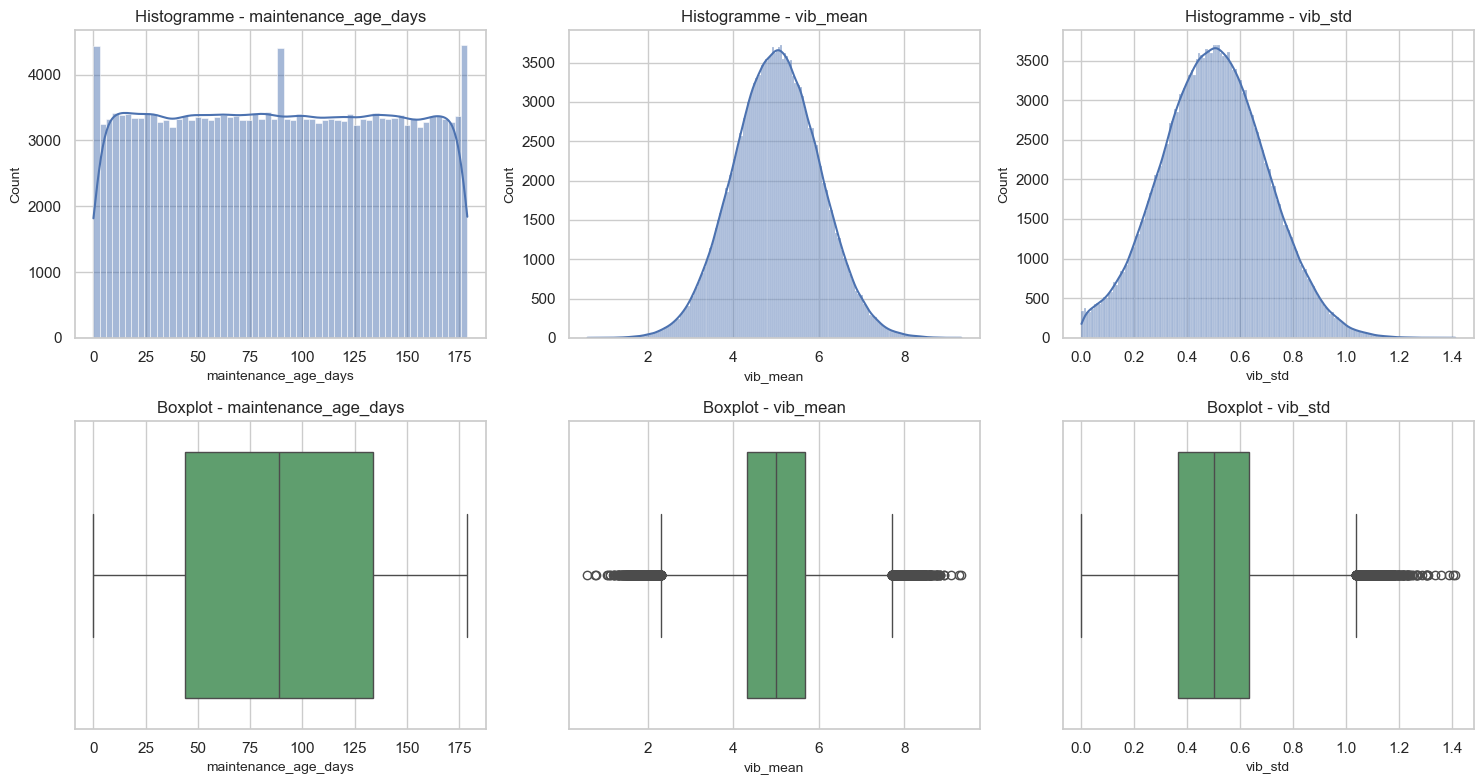

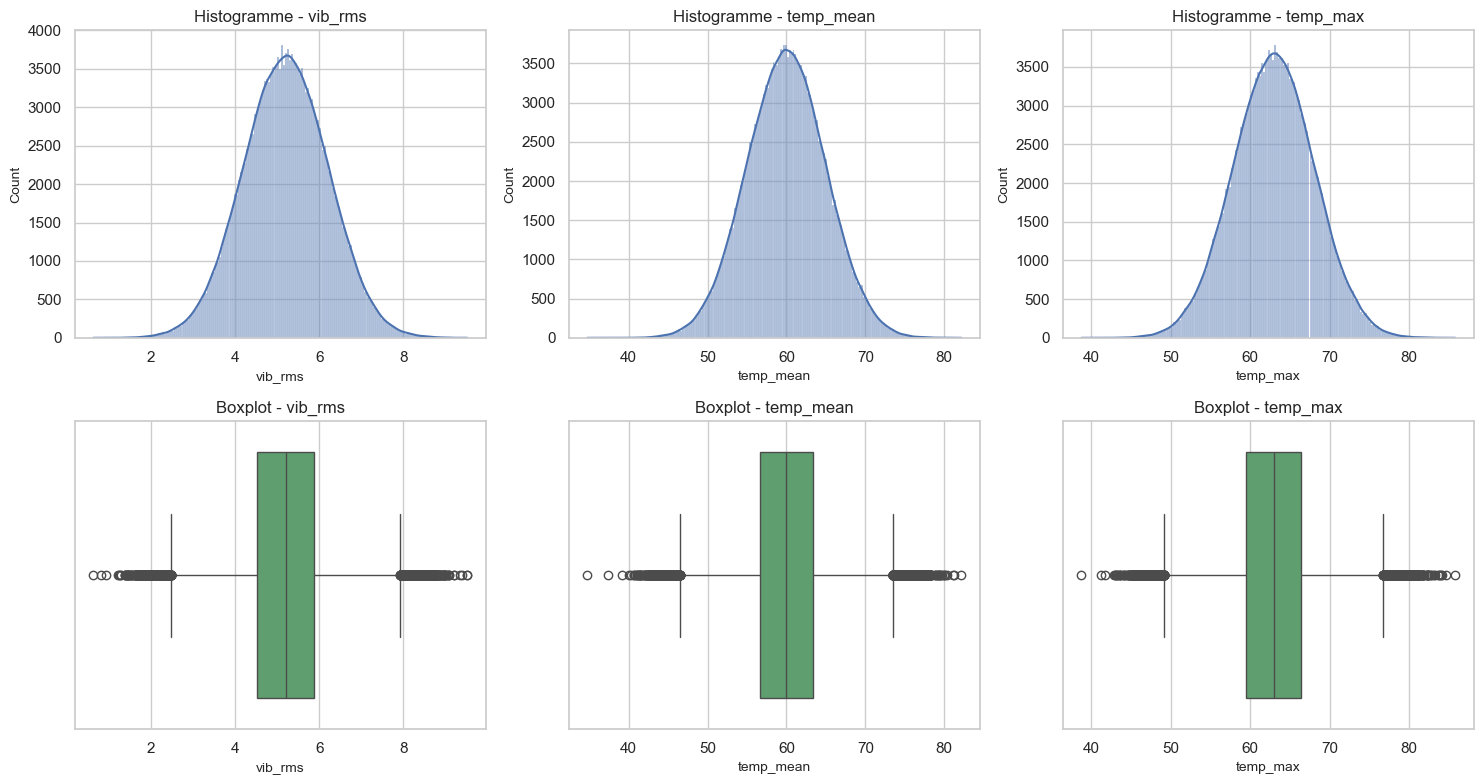

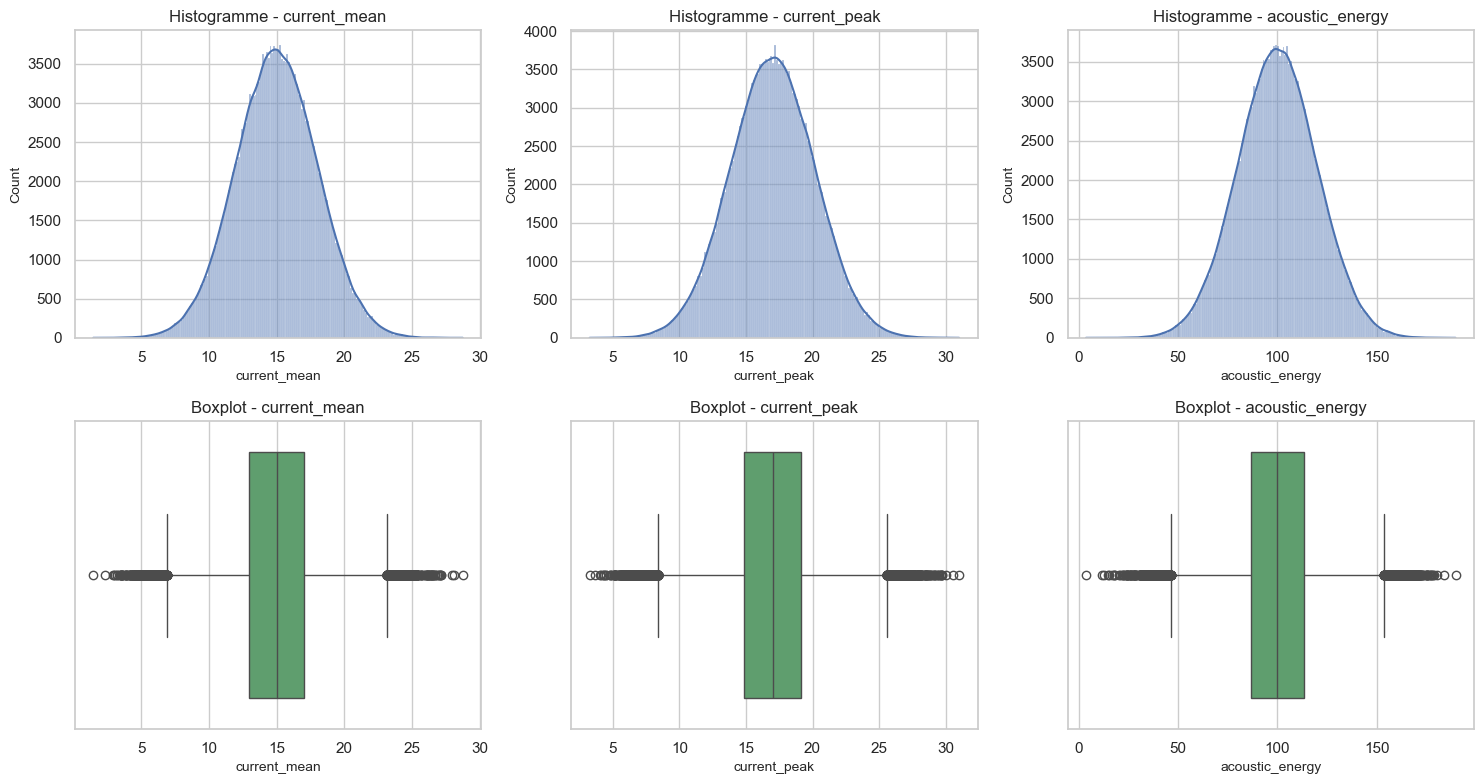

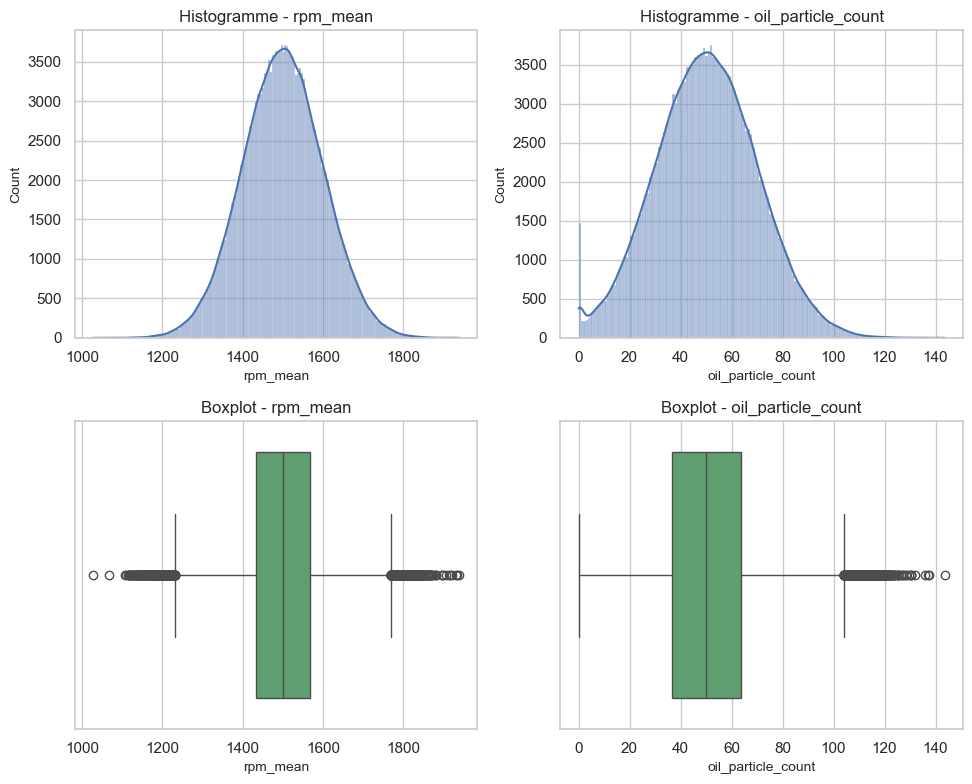

In [19]:
# Histogrammes + boxplots (batch)
cols = num_cols_no_target.copy()
n_cols = 3

for i in range(0, len(cols), n_cols):
    subset = cols[i:i+n_cols]

    fig, axes = plt.subplots(2, len(subset), figsize=(5*len(subset), 8))
    if len(subset) == 1:
        axes = np.array(axes).reshape(2, 1)

    for j, col in enumerate(subset):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[0, j], color='#4c72b0')
        axes[0, j].set_title(f'Histogramme - {col}')

        sns.boxplot(x=df[col], ax=axes[1, j], color='#55a868')
        axes[1, j].set_title(f'Boxplot - {col}')

    plt.tight_layout()
    plt.show()

### 3.1) Outliers, asymétrie et forme des distributions

,feature,skewness,kurtosis,outlier_count_iqr,outlier_pct_iqr
1,vib_mean,0.002268,-0.003885,1434,0.7170
9,rpm_mean,0.008105,-0.001816,1426,0.7130
3,vib_rms,0.001964,-0.002851,1426,0.7130
8,acoustic_energy,-0.003333,-0.006614,1418,0.7090
6,current_mean,0.001188,-0.000910,1394,0.6970
7,current_peak,-0.004456,-0.004628,1383,0.6915
5,temp_max,-0.003087,-0.016737,1361,0.6805
4,temp_mean,-0.001774,-0.018984,1359,0.6795
2,vib_std,0.067242,-0.153316,719,0.3595
10,oil_particle_count,0.039596,-0.105609,704,0.3520


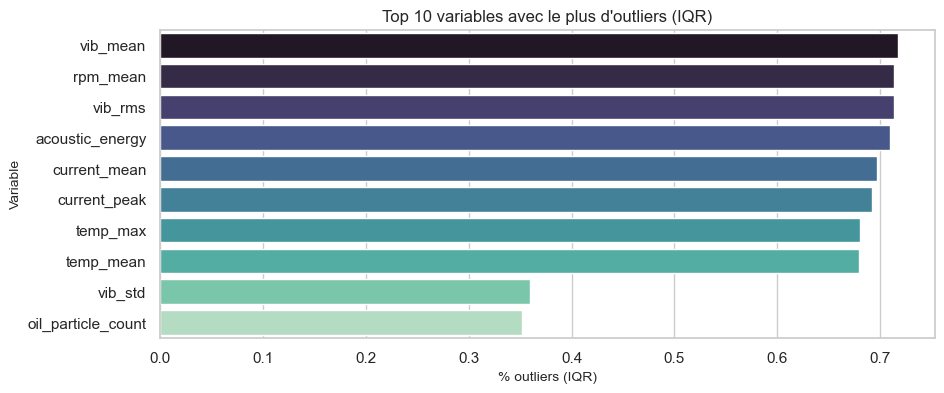

In [20]:
# Détection simple des outliers via IQR + mesure d'asymétrie
outlier_rows = []
for col in num_cols_no_target:
    series = df[col].dropna()
    if series.empty:
        continue
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        outlier_count = 0
    else:
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_count = int(((df[col] < low) | (df[col] > high)).sum())

    outlier_rows.append({
        'feature': col,
        'skewness': series.skew(),
        'kurtosis': series.kurt(),
        'outlier_count_iqr': outlier_count,
        'outlier_pct_iqr': 100 * outlier_count / len(df)
    })

outlier_report = pd.DataFrame(outlier_rows).sort_values('outlier_pct_iqr', ascending=False)
display(outlier_report)

plt.figure(figsize=(10,4))
sns.barplot(data=outlier_report.head(10), x='outlier_pct_iqr', y='feature', palette='mako')
plt.title('Top 10 variables avec le plus d\'outliers (IQR)')
plt.xlabel('% outliers (IQR)')
plt.ylabel('Variable')
plt.show()

## 4) Analyse de la cible et déséquilibre de classes

Taux de panne à 24h (classe 1): 17.90%


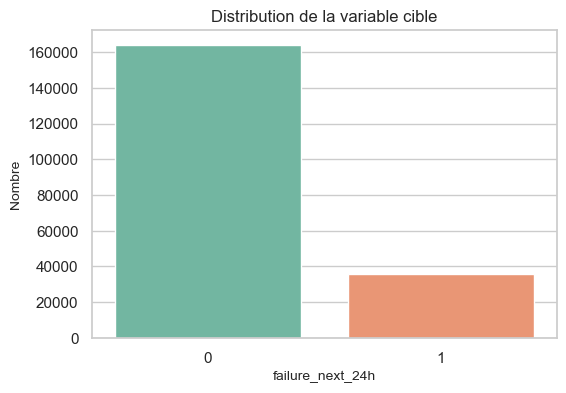

In [21]:
if 'failure_next_24h' in df.columns:
    target_rate = df['failure_next_24h'].mean()
    print(f'Taux de panne à 24h (classe 1): {target_rate:.2%}')

    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='failure_next_24h', palette='Set2')
    plt.title('Distribution de la variable cible')
    plt.xlabel('failure_next_24h')
    plt.ylabel('Nombre')
    plt.show()
else:
    print('La colonne failure_next_24h est absente du dataset.')

### 4.1) Signaux statistiques de la cible (corrélation et taille d'effet)

,feature,corr_with_target,cohens_d_1_vs_0,mean_0,mean_1,abs_cohens_d
0,maintenance_age_days,0.270462,0.732858,82.802423,119.456811,0.732858
10,oil_particle_count,0.007154,0.018662,50.019048,50.390626,0.018662
2,vib_std,-0.002959,-0.007719,0.500814,0.499282,0.007719
9,rpm_mean,-0.002456,-0.006408,1499.924064,1499.282848,0.006408
8,acoustic_energy,0.001541,0.004021,99.988899,100.069270,0.004021
5,temp_max,0.000960,0.002505,62.976443,62.989225,0.002505
4,temp_mean,0.000920,0.002401,59.980115,59.992134,0.002401
6,current_mean,0.000712,0.001856,14.995416,15.000998,0.001856
7,current_peak,-0.000397,-0.001036,16.996624,16.993342,0.001036
1,vib_mean,0.000353,0.000921,5.004927,5.005848,0.000921


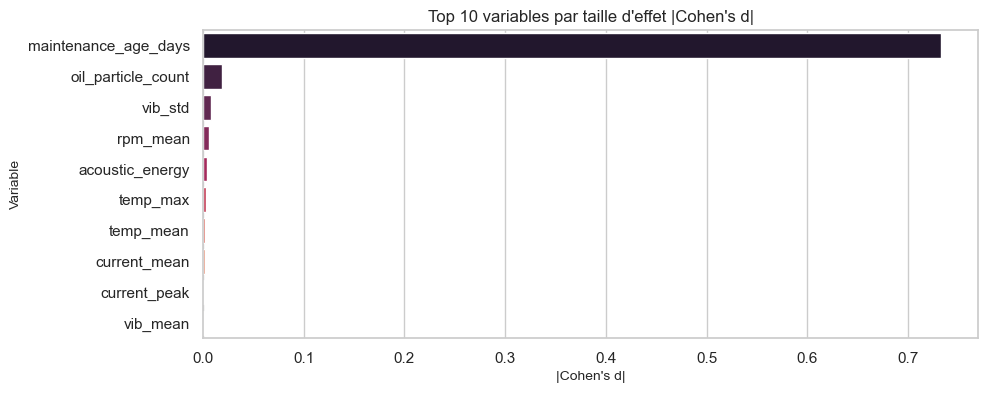

In [22]:
# Corrélations point-bisérielles + taille d'effet de Cohen's d
if 'failure_next_24h' in df.columns and num_cols_no_target:
    tmp = df[num_cols_no_target + ['failure_next_24h']].dropna().copy()

    def cohens_d(x0, x1):
        n0, n1 = len(x0), len(x1)
        if n0 < 2 or n1 < 2:
            return np.nan
        s0, s1 = np.var(x0, ddof=1), np.var(x1, ddof=1)
        sp = np.sqrt(((n0 - 1) * s0 + (n1 - 1) * s1) / (n0 + n1 - 2))
        if sp == 0:
            return 0.0
        return (np.mean(x1) - np.mean(x0)) / sp

    rows = []
    for col in num_cols_no_target:
        part = tmp[[col, 'failure_next_24h']].dropna()
        if part.empty:
            continue
        x0 = part.loc[part['failure_next_24h'] == 0, col].values
        x1 = part.loc[part['failure_next_24h'] == 1, col].values

        rows.append({
            'feature': col,
            'corr_with_target': part[col].corr(part['failure_next_24h']),
            'cohens_d_1_vs_0': cohens_d(x0, x1),
            'mean_0': np.mean(x0) if len(x0) else np.nan,
            'mean_1': np.mean(x1) if len(x1) else np.nan
        })

    effect_report = pd.DataFrame(rows)
    effect_report['abs_cohens_d'] = effect_report['cohens_d_1_vs_0'].abs()
    effect_report = effect_report.sort_values('abs_cohens_d', ascending=False)
    display(effect_report)

    plt.figure(figsize=(10,4))
    sns.barplot(data=effect_report.head(10), x='abs_cohens_d', y='feature', palette='rocket')
    plt.title('Top 10 variables par taille d\'effet |Cohen\'s d|')
    plt.xlabel('|Cohen\'s d|')
    plt.ylabel('Variable')
    plt.show()

### 4.2) Analyse bivariée (comparaison classe 0 vs classe 1)

,class_0,class_1,delta_1_minus_0
maintenance_age_days,82.802423,119.456811,36.654388
oil_particle_count,50.019048,50.390626,0.371578
acoustic_energy,99.988899,100.069270,0.080372
temp_max,62.976443,62.989225,0.012782
temp_mean,59.980115,59.992134,0.012019
current_mean,14.995416,15.000998,0.005582
vib_mean,5.004927,5.005848,0.000921
vib_rms,5.205329,5.205930,0.000601
vib_std,0.500814,0.499282,-0.001532
current_peak,16.996624,16.993342,-0.003282


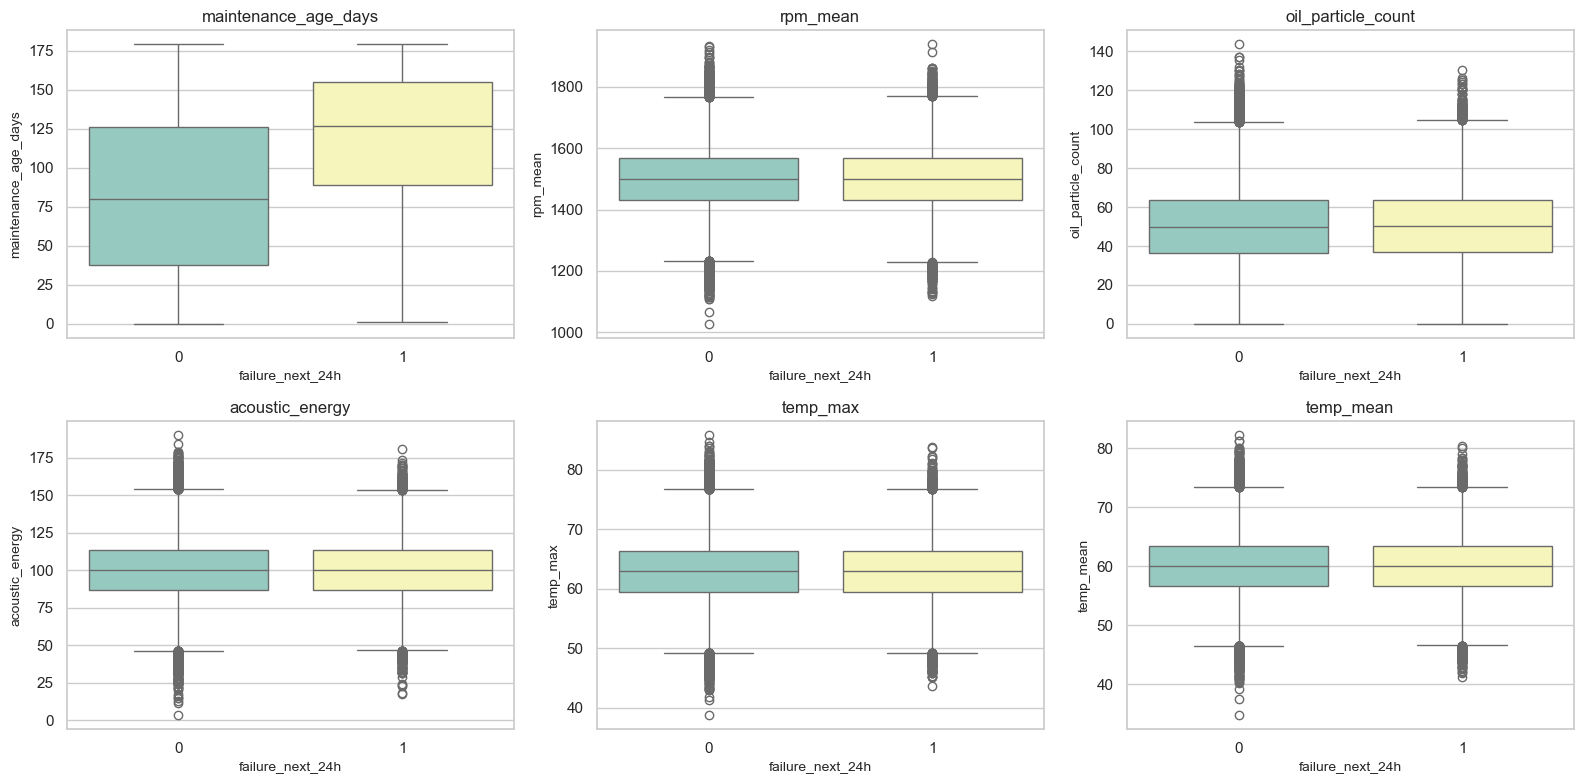

In [23]:
if 'failure_next_24h' in df.columns and num_cols_no_target:
    # Différence moyenne par classe
    mean_by_target = df.groupby('failure_next_24h')[num_cols_no_target].mean().T
    mean_by_target.columns = [f'class_{c}' for c in mean_by_target.columns]
    if {'class_0', 'class_1'}.issubset(mean_by_target.columns):
        mean_by_target['delta_1_minus_0'] = mean_by_target['class_1'] - mean_by_target['class_0']
    display(mean_by_target.sort_values(by=mean_by_target.columns[-1], ascending=False).head(15))

    # Boxplots ciblés
    top_features = (
        mean_by_target['delta_1_minus_0'].abs().sort_values(ascending=False).head(6).index.tolist()
        if 'delta_1_minus_0' in mean_by_target.columns else num_cols_no_target[:6]
    )

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for idx, feature in enumerate(top_features):
        sns.boxplot(data=df, x='failure_next_24h', y=feature, ax=axes[idx], palette='Set3')
        axes[idx].set_title(feature)

    for idx in range(len(top_features), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

,failure_rate,n
machine_type,,
Convoyeur,0.182135,49952
Presse,0.179663,49810
CNC,0.179046,50272
Robot,0.175079,49966


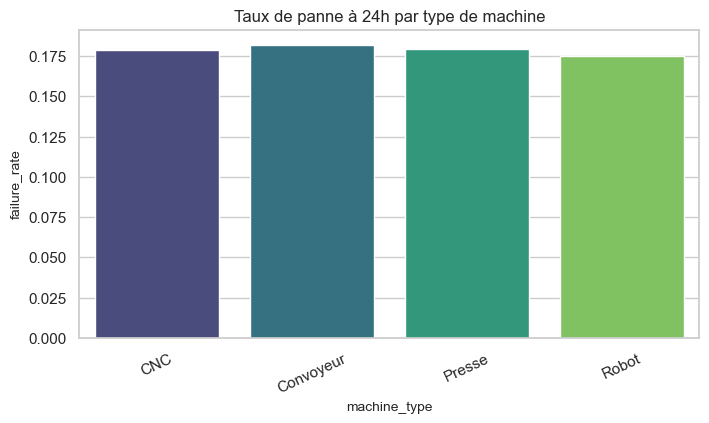

In [24]:
# Taux de pannes par type de machine
if {'machine_type', 'failure_next_24h'}.issubset(df.columns):
    failure_by_type = (
        df.groupby('machine_type')['failure_next_24h']
          .agg(['mean', 'count'])
          .rename(columns={'mean': 'failure_rate', 'count': 'n'})
          .sort_values('failure_rate', ascending=False)
    )
    display(failure_by_type)

    plt.figure(figsize=(8,4))
    sns.barplot(x=failure_by_type.index, y=failure_by_type['failure_rate'], palette='viridis')
    plt.title('Taux de panne à 24h par type de machine')
    plt.xlabel('machine_type')
    plt.ylabel('failure_rate')
    plt.xticks(rotation=25)
    plt.show()

## 5) Analyse temporelle

Période couverte:
2025-01-01 00:00:00 -> 2025-01-24 03:33:10


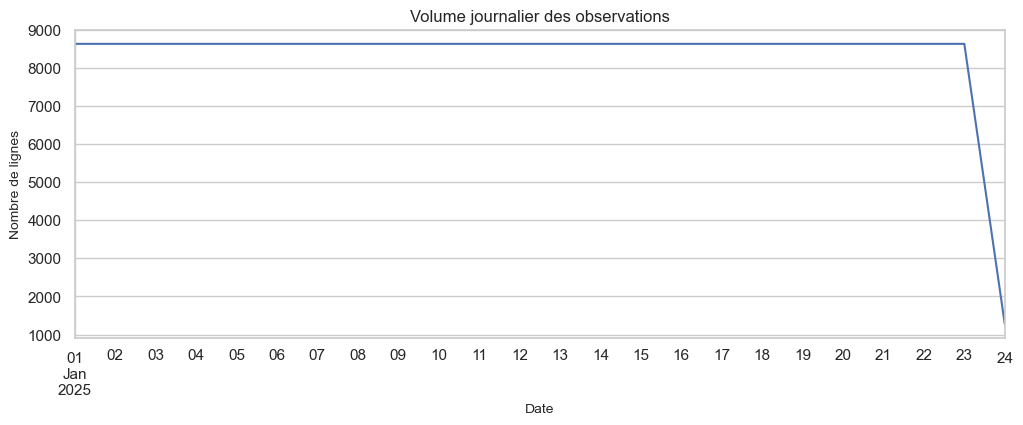

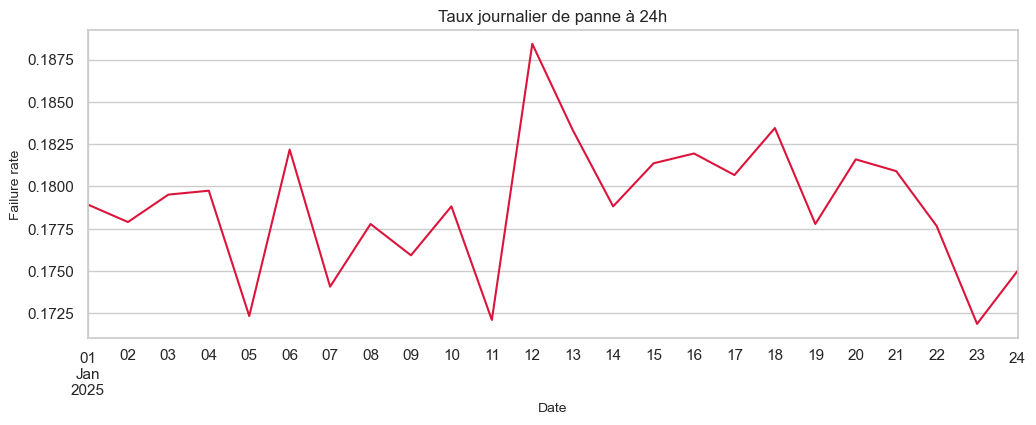

In [25]:
if 'timestamp' in df.columns and pd.api.types.is_datetime64_any_dtype(df['timestamp']):
    print('Période couverte:')
    print(df['timestamp'].min(), '->', df['timestamp'].max())

    # Evolution journalière du nombre d'observations
    daily_n = df.set_index('timestamp').resample('D').size()
    plt.figure(figsize=(12,4))
    daily_n.plot()
    plt.title('Volume journalier des observations')
    plt.xlabel('Date')
    plt.ylabel('Nombre de lignes')
    plt.show()

    # Evolution journalière du taux de panne
    if 'failure_next_24h' in df.columns:
        daily_failure_rate = df.set_index('timestamp')['failure_next_24h'].resample('D').mean()
        plt.figure(figsize=(12,4))
        daily_failure_rate.plot(color='crimson')
        plt.title('Taux journalier de panne à 24h')
        plt.xlabel('Date')
        plt.ylabel('Failure rate')
        plt.show()
else:
    print('Colonne timestamp absente ou mal convertie.')

### 5.1) Saisonnalité (heure et jour de semaine)

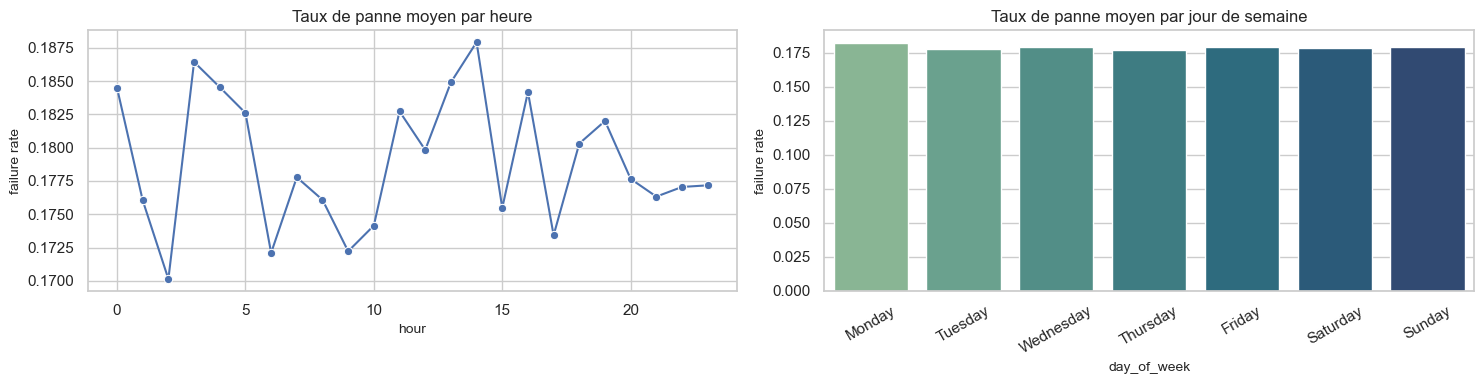

In [26]:
if 'timestamp' in df.columns and 'failure_next_24h' in df.columns:
    ts_df = df.dropna(subset=['timestamp']).copy()
    ts_df['hour'] = ts_df['timestamp'].dt.hour
    ts_df['day_of_week'] = ts_df['timestamp'].dt.day_name()

    hour_rate = ts_df.groupby('hour')['failure_next_24h'].mean().reset_index()

    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_rate = ts_df.groupby('day_of_week')['failure_next_24h'].mean().reindex(day_order).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(15,4))
    sns.lineplot(data=hour_rate, x='hour', y='failure_next_24h', marker='o', ax=axes[0])
    axes[0].set_title('Taux de panne moyen par heure')
    axes[0].set_ylabel('failure rate')

    sns.barplot(data=day_rate, x='day_of_week', y='failure_next_24h', ax=axes[1], palette='crest')
    axes[1].set_title('Taux de panne moyen par jour de semaine')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].set_ylabel('failure rate')

    plt.tight_layout()
    plt.show()

## 6) Corrélations globales et redondances potentielles

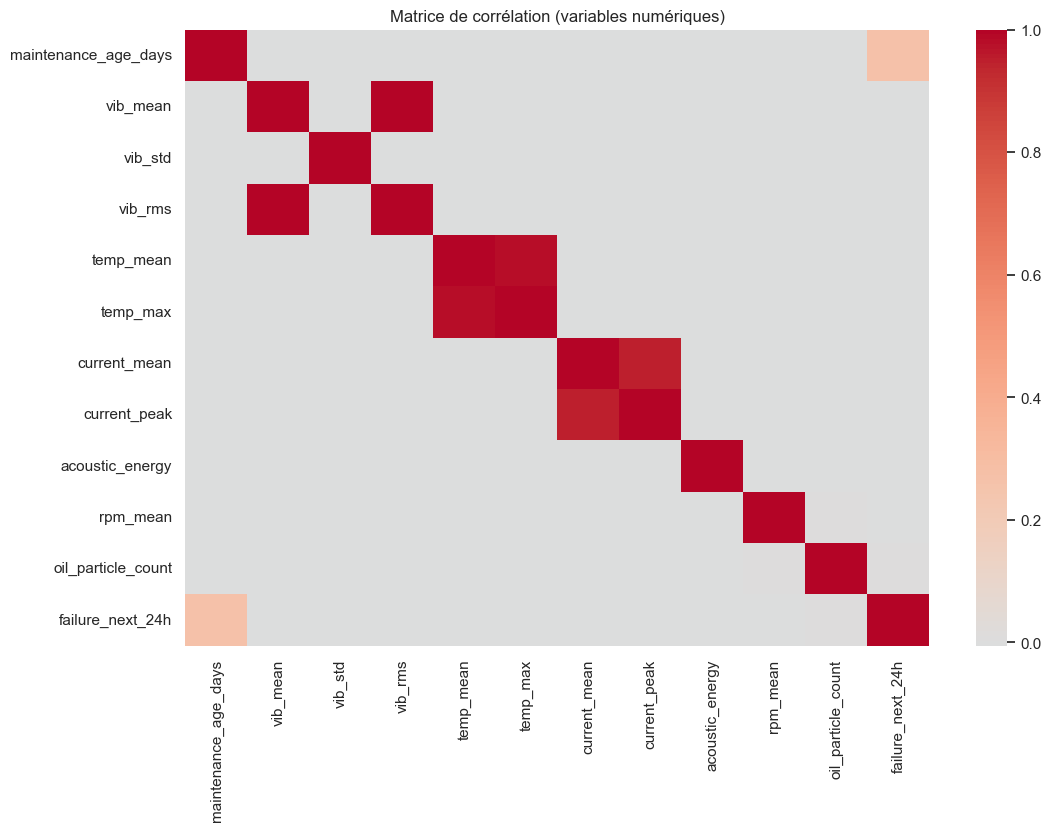

Top corrélations positives avec la cible:


failure_next_24h        1.000000
maintenance_age_days    0.270462
oil_particle_count      0.007154
acoustic_energy         0.001541
temp_max                0.000960
temp_mean               0.000920
current_mean            0.000712
vib_mean                0.000353
vib_rms                 0.000229
current_peak           -0.000397
Name: failure_next_24h, dtype: float64

Top corrélations négatives avec la cible:


oil_particle_count    0.007154
acoustic_energy       0.001541
temp_max              0.000960
temp_mean             0.000920
current_mean          0.000712
vib_mean              0.000353
vib_rms               0.000229
current_peak         -0.000397
rpm_mean             -0.002456
vib_std              -0.002959
Name: failure_next_24h, dtype: float64

In [27]:
corr_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(corr_cols) >= 2:
    corr = df[corr_cols].corr(numeric_only=True)

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
    plt.title('Matrice de corrélation (variables numériques)')
    plt.show()

    # Corrélation avec la cible
    if 'failure_next_24h' in corr.columns:
        target_corr = corr['failure_next_24h'].sort_values(ascending=False)
        print('Top corrélations positives avec la cible:')
        display(target_corr.head(10))
        print('Top corrélations négatives avec la cible:')
        display(target_corr.tail(10))

## 7) Préparation à l'entraînement du modèle

Dans cette section, on prépare un schéma de split robuste et un pipeline de prétraitement compatible production.

In [3]:
# Préparation des features, split temporel, et paramétrage d'entraînement
if 'pd' not in globals():
    import pandas as pd
if 'np' not in globals():
    import numpy as np

if 'df' not in globals():
    CSV_PATH = 'AI4BMI_predictive_maintenance_dataset.csv'
    df = pd.read_csv(CSV_PATH)
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

feature_candidates = [
    'machine_type',
    'maintenance_age_days', 'vib_mean', 'vib_std', 'vib_rms',
    'temp_mean', 'temp_max', 'current_mean', 'current_peak',
    'acoustic_energy', 'rpm_mean', 'oil_particle_count'
]

target_col = 'failure_next_24h'
available_features = [c for c in feature_candidates if c in df.columns]

model_df = df.dropna(subset=['timestamp', target_col]).sort_values('timestamp').copy()
X = model_df[available_features].copy()
y = model_df[target_col].astype(int).copy()

# Split temporel: 80% train, 20% test (évite la fuite temporelle)
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

num_features = [c for c in X_train.columns if c != 'machine_type']
cat_features = [c for c in ['machine_type'] if c in X_train.columns]

print('Features retenues:', available_features)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Taux de panne Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

# Poids de classes conseillé pour gérer le déséquilibre
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight_ratio = (neg / pos) if pos > 0 else np.nan
print(f"Poids conseillé classe 1 (approx): {class_weight_ratio:.2f}")

# Configuration pipeline (sans entraînement ici)
try:
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
        ],
        remainder='drop'
    )

    print('Préprocesseur sklearn prêt pour l\'entraînement.')
except Exception as e:
    print('Préprocesseur non initialisé (scikit-learn manquant).', str(e))

Features retenues: ['machine_type', 'maintenance_age_days', 'vib_mean', 'vib_std', 'vib_rms', 'temp_mean', 'temp_max', 'current_mean', 'current_peak', 'acoustic_energy', 'rpm_mean', 'oil_particle_count']
Train: (160000, 12), Test: (40000, 12)
Taux de panne Train: 17.93% | Test: 17.78%
Poids conseillé classe 1 (approx): 4.58
Préprocesseur sklearn prêt pour l'entraînement.


## 8) Conclusions EDA et implications pour l'entraînement

### Conclusions principales
- **Dataset propre et exploitable** : 200 000 lignes, 15 variables, pas de valeurs manquantes ni doublons stricts.
- **Écart documentation vs données** : 9 variables décrites dans la doc ne sont pas présentes dans le CSV (`operating_mode`, `temp_gradient`, `current_std`, etc.).
- **Cible déséquilibrée** : `failure_next_24h = 1` représente ~17.9% des cas (classe minoritaire).
- **Signal prédictif dominant** : `maintenance_age_days` est de loin la variable la plus informative (corrélation et taille d'effet nettement supérieures aux autres).
- **Autres capteurs** : effet univarié faible pris isolément ; leur utilité viendra surtout des interactions non linéaires et de combinaisons de variables.
- **Par type de machine** : taux de panne proches entre catégories (~17.5% à ~18.2%), donc `machine_type` seul discrimine peu.

### Conséquences directes pour le modèle
1. **Split temporel obligatoire** (et non aléatoire) pour éviter la fuite d'information.
2. **Métriques cibles** : Recall, F1, PR-AUC en priorité (accuracy insuffisante avec déséquilibre).
3. **Gestion du déséquilibre** : `class_weight='balanced'` ou pondération explicite de la classe 1.
4. **Baselines recommandées** :
   - Modèle linéaire pondéré (Logistic Regression) pour l'interprétabilité,
   - Modèle non linéaire (Random Forest / XGBoost) pour capturer interactions.
5. **Validation** : comparaison Train/Test temporel + matrice de confusion + courbe PR.

### Plan d'entraînement recommandé
- Étape 1 : entraîner une baseline interprétable avec le préprocesseur (standardisation + encodage `machine_type`).
- Étape 2 : ajuster le seuil de décision pour maximiser le rappel sans explosion des faux positifs.
- Étape 3 : entraîner un modèle arbre/boosting et comparer sur PR-AUC, Recall et coût métier.
- Étape 4 : expliquer le modèle final (importance des variables, SHAP si disponible).